<a href="https://colab.research.google.com/github/OliverG03/CNN-Implementation-Facial-Emotion-Recognition/blob/main/Milestone3Updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Model:**	CNN	with	3	convolutional	layers (implemented	from	scratch)
**Summary:**	This	task	involves	detecting	emotions	(e.g.,	happy,	sad,angry)	from	facial	images.	The	dataset	contains	grayscale	images	of	48x48	pixels	representing	seven	emotion	classes.

#Importing

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Upload the FER-2013.zip file
from google.colab import files
uploaded = files.upload()  # This will open a file chooser

# Step 2: Unzip the uploaded file into a folder named 'FER-2013', overwrite if files exist
import zipfile
import io
import os

zip_filename = list(uploaded.keys())[0]  # Get the uploaded file name
extract_path = "FER-2013"

# Create target folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Unzipped '{zip_filename}' to '{extract_path}' successfully!")

Saving FER-2013.zip to FER-2013.zip
Unzipped 'FER-2013.zip' to 'FER-2013' successfully!


In [ ]:
train_dir = "FER-2013/FER-2013/train"
test_dir  = "FER-2013/FER-2013/test"

#Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(48, 48),
    batch_size=64, #if issues change to 32
    color_mode="grayscale",
    class_mode="categorical",
    subset="training"
)
validation_generator = validation_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
model = Sequential()
# Conv Layer 1 — 32 filters (lightweight for CPU)
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Layer 2 — 32 filters
model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Conv Layer 3 — 32 filters
model.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully connected
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ── Compile
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [ ]:
# ── Callbacks
callbacks = [
    ModelCheckpoint(
        filepath='model_weights.weights.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(          # from Model 2 — helps on CPU where you run fewer epochs
        monitor='val_accuracy',
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1
    ),
    EarlyStopping(              # stops training if no improvement — saves CPU time
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=60,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=callbacks
)


Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2146 - loss: 2.1898
Epoch 1: val_accuracy improved from None to 0.25021, saving model to model_weights.weights.h5

Epoch 1: finished saving model to model_weights.weights.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - accuracy: 0.2373 - loss: 2.0005 - val_accuracy: 0.2502 - val_loss: 1.8359 - learning_rate: 0.0010
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2940 - loss: 1.7770
Epoch 2: val_accuracy improved from 0.25021 to 0.31193, saving model to model_weights.weights.h5

Epoch 2: finished saving model to model_weights.weights.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 656s 1s/step - accuracy: 0.3164 - loss: 1.7234 - val_accuracy: 0.3119 - val_loss: 1.6824 - learning_rate: 0.0010
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3742 - loss: 1.5894
Epoch 3: val_accuracy improved from 0.31193 to 0.45444, saving model to model_weights.weights.h5

Epoch 3: finished saving model to model_weights.weig

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,294,679 (31.64 MB)

 Trainable params: 2,764,423 (10.55 MB)

 Non-trainable params: 1,408 (5.50 KB)

 Optimizer params: 5,528,848 (21.09 MB)

113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 247ms/step
       PERFORMANCE METRICS
Inference Time:     28.28 seconds
CPU Usage:          2.0%
RAM Used:           1.72 GB
Estimated Power:    0.30 W
Estimated Energy:   8.49 J

     CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry       0.12      0.12      0.12       958
     Disgust       0.00      0.00      0.00       111
        Fear       0.16      0.07      0.10      1024
       Happy       0.25      0.26      0.25      1774
         Sad       0.17      0.25      0.21      1233
    Surprise       0.16      0.14      0.15      1247
     Neutral       0.11      0.12      0.11       831

    accuracy                           0.17      7178
   macro avg       0.14      0.14      0.13      7178
weighted avg       0.17      0.17      0.17      7178



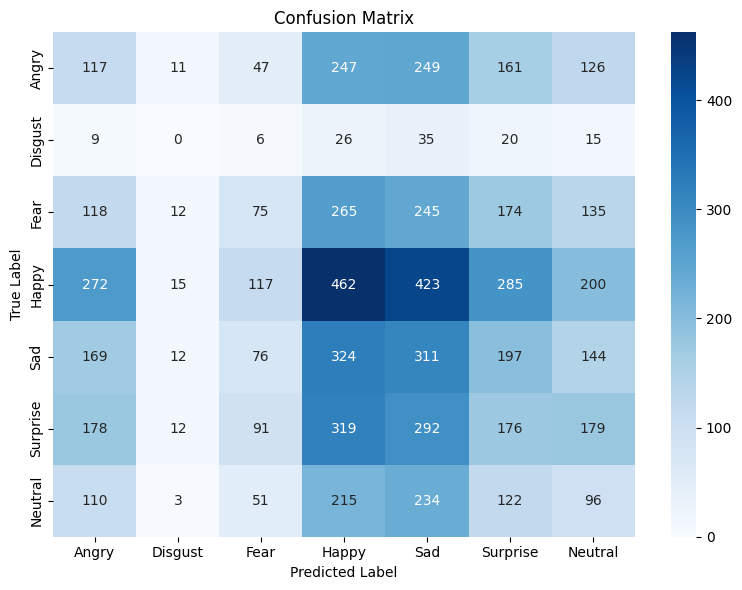

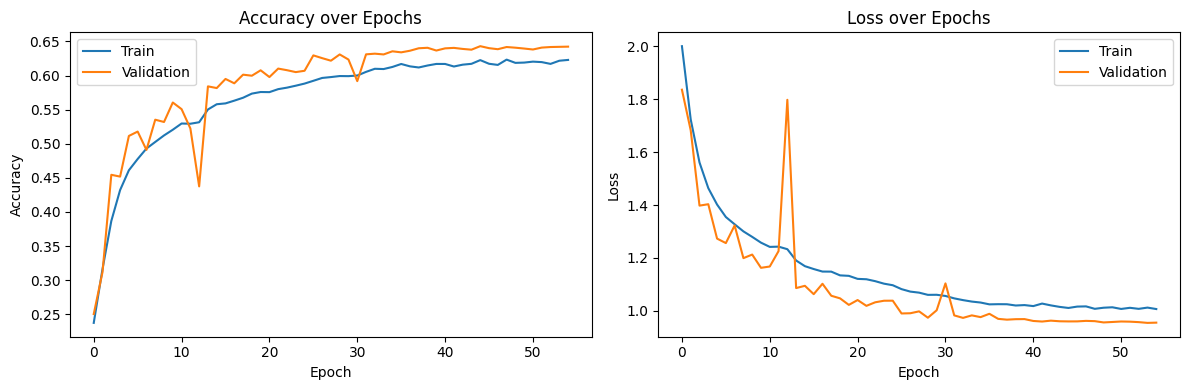

In [ ]:
import time
import psutil
import threading
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── 1. TIME & POWER METRICS ──────────────────────────────
cpu_readings = []
tracking = True

def track_cpu():
    while tracking:
        cpu_readings.append(psutil.cpu_percent(interval=0.5))

# Start tracking CPU in background
tracker = threading.Thread(target=track_cpu)
tracker.start()

start_time = time.time()

# Run predictions
y_pred_probs = model.predict(validation_generator)

end_time = time.time()

# Stop tracking
tracking = False
tracker.join()

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes

inference_time = end_time - start_time
avg_cpu = sum(cpu_readings) / len(cpu_readings) if cpu_readings else 0
ram_used = psutil.virtual_memory().used / (1024 ** 3)

tdp_watts = 15
estimated_power_w = tdp_watts * (avg_cpu / 100)
estimated_energy_j = estimated_power_w * inference_time

print("=" * 40)
print("       PERFORMANCE METRICS")
print("=" * 40)
print(f"Inference Time:     {inference_time:.2f} seconds")
print(f"Avg CPU Usage:      {avg_cpu:.1f}%")
print(f"RAM Used:           {ram_used:.2f} GB")
print(f"Estimated Power:    {estimated_power_w:.2f} W")
print(f"Estimated Energy:   {estimated_energy_j:.2f} J")

# ── 2. MODEL ACCURACY METRICS ────────────────────────────
class_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

print("\n" + "=" * 40)
print("     CLASSIFICATION REPORT")
print("=" * 40)
print(classification_report(y_true, y_pred, target_names=class_names))

# ── 3. CONFUSION MATRIX ──────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ── 4. TRAINING HISTORY PLOTS ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import time

# Total training time
training_start = time.time()
history = model.fit(...)
training_end = time.time()

total_training_time = training_end - training_start
time_per_epoch = total_training_time / len(history.history['loss'])

print(f"Total Training Time: {total_training_time/3600:.2f} hours")
print(f"Average Time/Epoch: {time_per_epoch:.2f} seconds")
print(f"Average Time/Step:  {time_per_epoch/449:.2f} seconds")

ValueError: Unrecognized data type: x=Ellipsis (of type <class 'ellipsis'>)

In [ ]:
# Peak and final accuracy
print(f"Best Val Accuracy:  {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Best Val Loss:      {min(history.history['val_loss']):.4f}")
print(f"Epochs Run:         {len(history.history['loss'])}")
print(f"Epochs to 60%:      {next(i+1 for i,v in enumerate(history.history['val_accuracy']) if v >= 0.60)}")

Best Val Accuracy:  64.31%
Best Val Loss:      0.9544
Epochs Run:         55
Epochs to 60%:      18


In [ ]:
import psutil
import platform
import time

def get_cpu_info():
    UNIT = 1024 * 1024  # MB

    # CPU Info
    print("Processor:        ", platform.processor())
    print("CPU Cores:        ", psutil.cpu_count(logical=False))
    print("Logical CPUs:     ", psutil.cpu_count(logical=True))

    # RAM Info
    memoryInfo = psutil.virtual_memory()
    print("memoryInfo.total: ", memoryInfo.total / UNIT, "MB")
    print("memoryInfo.used:  ", memoryInfo.used / UNIT, "MB")
    print("memoryInfo.free:  ", memoryInfo.free / UNIT, "MB")
    print("memoryInfo.free:  ", memoryInfo.free / memoryInfo.total)
    print("memoryInfo.used:  ", memoryInfo.used / memoryInfo.total)

    # CPU Usage
    cpuUtilRate = psutil.cpu_percent(interval=1)
    print("cpuUtilRate:      ", cpuUtilRate, "%")

    # Temperature (may not work on all Colab instances)
    try:
        temps = psutil.sensors_temperatures()
        if temps:
            for name, entries in temps.items():
                for entry in entries:
                    print(f"cpuTemperature:    {entry.current} C ({name})")
        else:
            print("cpuTemperature:    Not available on this system")
    except AttributeError:
        print("cpuTemperature:    Not supported on this OS")

    # Power estimate (no direct CPU power API, so we estimate)
    tdp_watts = 15  # typical Colab CPU TDP
    estimated_power = tdp_watts * (cpuUtilRate / 100)
    print("estimatedPower:   ", round(estimated_power, 2), "W")


def get_current_energy():
    # Track energy over a time window since CPUs have no direct energy counter
    tdp_watts = 15
    interval = 1  # second
    cpu_usage = psutil.cpu_percent(interval=interval)
    estimated_power_w = tdp_watts * (cpu_usage / 100)
    estimated_energy_j = estimated_power_w * interval
    estimated_energy_mj = estimated_energy_j * 1000  # millijoules to match pynvml units
    return estimated_energy_mj


get_cpu_info()
get_current_energy()

Processor:         x86_64
CPU Cores:         1
Logical CPUs:      2
memoryInfo.total:  12975.53515625 MB
memoryInfo.used:   1805.25390625 MB
memoryInfo.free:   8638.51171875 MB
memoryInfo.free:   0.6657537908630334
memoryInfo.used:   0.13912751069696366
cpuUtilRate:       20.1 %
cpuTemperature:    Not available on this system
estimatedPower:    3.02 W


375.0

In [ ]:
import time

training_start = time.time()

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=60,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=callbacks
)

training_end = time.time()

total_training_time = training_end - training_start
time_per_epoch = total_training_time / len(history.history['loss'])

print(f"Total Training Time: {total_training_time/3600:.2f} hours")
print(f"Average Time/Epoch:  {time_per_epoch:.2f} seconds")
print(f"Average Time/Step:   {time_per_epoch/449:.2f} seconds")